# Camcoadd Setup for DR2 (`loa`)

This notebook sets up and enables execution of jobs to coadd DESI spectra across cameras for the "loa" (DR2) data assembly.

A. Bolton, 2025 April

### Section 1: Identify the input files to operate on

In [1]:
# Imports and setups:
# (may not need all these)
import os
import numpy as np
import healpy as hp
from glob import glob
import fitsio
from collections import defaultdict
import desispec.io
import time
import pandas as pd

import matplotlib.pyplot as plt
import h5py
from astropy.table import Table
from astropy.io import fits
from astropy.io import ascii
from redrock import templates
from redrock import rebin
from redrock import targets
from redrock import zscan
from desispec import coaddition
from prospect import viewer

In [2]:
# THINGS THAT NEED TO BE SPECIFIED

# Path to DESI spectroscopic redutions:
desi_spectro_redux = '/global/cfs/cdirs/desi/spectro/redux/'

# Spectroscopic product to work on:
specprod = 'loa'

# Flavor of coadds to work with:
fileflavor = 'healpix'

# Root path for output files, with inferior file hierarchy analogous to desi_spectro_redux:
outroot = '/global/cfs/cdirs/desi/science/gqp/camcoadd/'

# List of surveys to work on:
survey_list = ['cmx', 'special', 'sv1', 'sv2', 'sv3', 'main']

# List of programs to work on:
program_list = ['backup', 'bright', 'dark', 'other']

In [3]:
# Set the output directory path:
outdir = outroot + specprod

# Set the input directory path to search under:
searchdir = desi_spectro_redux + specprod + '/' + fileflavor

# Figure out which of the survey-plus-program combos exist:
s_p_combos = []
for this_survey in survey_list:
        for this_program in program_list:
                this_combo = this_survey + '/' + this_program
                if os.path.exists(searchdir + '/' + this_combo):
                        s_p_combos.append(this_combo)

# Get a full list of lowest-level directories:
healdir_list = []
for this_combo in s_p_combos:
        healdir_list += glob(searchdir + '/' + this_combo + '/*/*')

# Pick out the path extension that will be common to both the input and the output dirs:
com_path = [this_dir[this_dir.find(specprod+'/'+fileflavor):] for this_dir in healdir_list]

# Translate into target output directories:
healout_list = [this_dir.replace(searchdir, outdir + '/' + fileflavor, 1) for this_dir in healdir_list]

ndir = len(healdir_list)
print('Found ', ndir, ' input directories')

Found  56780  input directories


In [4]:
# Print out the list of survey/program combos that will be included
print(s_p_combos)
# Before we had:
#['cmx/other', 'special/backup', 'special/bright', 'special/dark', 'special/other', 'sv1/backup',
#'sv1/bright', 'sv1/dark', 'sv1/other', 'sv2/backup', 'sv2/bright', 'sv2/dark', 'sv3/backup',
#'sv3/bright', 'sv3/dark', 'main/backup', 'main/bright', 'main/dark']

['cmx/other', 'special/backup', 'special/bright', 'special/dark', 'sv1/backup', 'sv1/bright', 'sv1/dark', 'sv1/other', 'sv2/backup', 'sv2/bright', 'sv2/dark', 'sv3/backup', 'sv3/bright', 'sv3/dark', 'main/backup', 'main/bright', 'main/dark']


In [5]:
# Create input filename lists, to test for existence:

cfile = [] # Input coadd file list
zfile = [] # Input redshift-output file list
ofile = [] # Output camcoadd file list
for idir in range(ndir):
    inputdir = healdir_list[idir]  # Current input directory
    outputdir = healout_list[idir] # Current output directory
    hp_string = inputdir.split('/')[-1] # healpix string
    hs_string = inputdir.split('/')[-2] # healpix substring
    pr_string = inputdir.split('/')[-3] # program string
    su_string = inputdir.split('/')[-4] # survey string
    fn_string = su_string + "-" + pr_string + "-" + hp_string # Base filename string
    cfile.append(inputdir + "/" + "coadd-" + fn_string + ".fits")
    zfile.append(inputdir + "/" + "redrock-" + fn_string + ".fits")
    ofile.append(outputdir + "/" + "camcoadd-" + fn_string + ".fits")

In [6]:
# Test for existence of the input files:
# (This takes a bit of time, go get a coffee...)
#ctest = np.asarray([os.path.exists(this_file) for this_file in cfile])
#ztest = np.asarray([os.path.exists(this_file) for this_file in zfile])

In [7]:
#print('Number of expected coadd files not found:    ', (~ctest).sum())
#print('Number of expected redshift files not found: ', (~ctest).sum())

Number of expected coadd files not found:     0
Number of expected redshift files not found:  0


In [8]:
# Get sizes of files:
csize = np.asarray([os.path.getsize(this_file) for this_file in cfile])
zsize = np.asarray([os.path.getsize(this_file) for this_file in zfile])

In [9]:
# How many terabytes?
csize.sum() / 1.e12

28.62727193952

### Section 2: Randomize the order of the files and separate into chunks

We will launch multiple parallel jobs on a single node.

For the June 2024 "iron" run, we used an exclusive Perlmutter node with 128 CPU cores and 512 GB RAM.

The resource is probably memory-limited, not CPU-limited.

We chunked into 64 chunks, giving each chunk-job 8GB.

Since the files have very different sizes, we randomize the order before separating into chunks, so that each chunk covers approximately the same distribution of file sizes.

In [15]:
# Set number of chunks and compute index breakpoints:
nchunk = 64 # for 512GB perlmutter node, 64 chunks gives 8GB per process
chunksiz = ndir / float(nchunk)
ichunk = np.round(chunksiz * np.arange(nchunk+1)).astype(np.int64)
ichunk[0] = 0           # JIK
ichunk[nchunk] = ndir   # JIK

### Section 3: Create the files for execution

We first create 64 separate files, one for each chunk-job.

Then we create a single file to launch all those jobs in background.

In [22]:
# Create filenames to serve as batch arguments:
fnames = ['camcoadd_exec_'+str(idx+1)+'.py' for idx in range(nchunk)]

In [23]:
# Create command strings:
cstrings = []
for i in range(ndir):
    cstrings.append("desi_camcoadd_healpix('" + healdir_list[i] + "','" + healout_list[i] + "')")

In [24]:
# Loop over chunks to create the files for execution:
for i in range(nchunk):
    f_this = open(fnames[i], 'w')
    f_this.write('from camcoadd_funcs import desi_camcoadd_healpix\n')
    for j in rand_idx[ichunk[i]:ichunk[i+1]]:
        f_this.write(cstrings[j]+'\n')
    f_this.close()

In [25]:
# Make the file for execution:
f_this = open(f'camcoadd_batch_{specprod}', 'w')
for this_fname in fnames:
    f_this.write('python ' + this_fname + ' &' + '\n')
f_this.close()

### Section 4: Commands for actual execution on exclusive node

In the future we probably want to use Slurm but we took a shortcut here for iron/DR1 in 2024.

Completing all 36634 files took about 2 to 3 hours on a Perlmutter exclusive node.

In [ ]:
# Command to setup DESI stack:
# source /global/common/software/desi/desi_environment.sh

# Command to make the batch script executable:
# chmod 770 camcoadd_batch_iron

# Command to execute: ./camcoadd_batch_iron

# Command to clean up output files:
# ---> !! DANGER !! DON'T USE THIS UNLESS YOU WANT TO DELETE ALL YOUR OUTPUTS !! <---
# rm -rf /global/cfs/cdirs/desi/science/gqp/camcoadd/iron/*

# Command to count the numner of output files (fails when list gets too long):
# ls /global/cfs/cdirs/desi/science/gqp/camcoadd/iron/healpix/*/*/*/*/camcoadd*.fits | wc

### Section 5: Check for the presence of expected outputs

In [8]:
# (Output filename list creted above.)
otest = np.asarray([os.path.exists(this_file) for this_file in ofile])

In [9]:
print('Number of expected output files not found: ', (~otest).sum())

Number of expected output files not found:  0


In [39]:
# Get sizes of files:
osize = np.asarray([os.path.getsize(this_file) for this_file in ofile])

In [40]:
# How many terabytes?
osize.sum() / 1.e12

15.06706319808

In [7]:
ofile[1500]

('/global/cfs/cdirs/desi/science/gqp/camcoadd/iron/healpix/sv1/bright/52/5214/camcoadd-sv1-bright-5214.fits',
 '/global/cfs/cdirs/desi/science/gqp/camcoadd/iron/healpix/sv1/bright/52/5214/camcoadd-sv1-bright-5214.fits')

### Section 6: Spot-check results

In [144]:
# Pick a few random file-pairs (input and output):
#idx = 30000
#idx = 16000
#idx = 25000
idx = 5000
spec_struc = desispec.io.read_spectra(cfile[idx])
spec_struc_2 = desispec.io.read_spectra(ofile[idx])

INFO:spectra.py:391:read_spectra: iotime 0.739 sec to read coadd-main-backup-12170.fits at 2024-06-25T16:01:04.430379
INFO:spectra.py:391:read_spectra: iotime 0.611 sec to read camcoadd-main-backup-12170.fits at 2024-06-25T16:01:05.363757


In [145]:
# Test for same number of spectra:
print(spec_struc.num_spectra())
spec_struc.num_spectra() == spec_struc_2.num_spectra()

432


True

In [146]:
# Initiate spectrum-plotting index:
j = -1

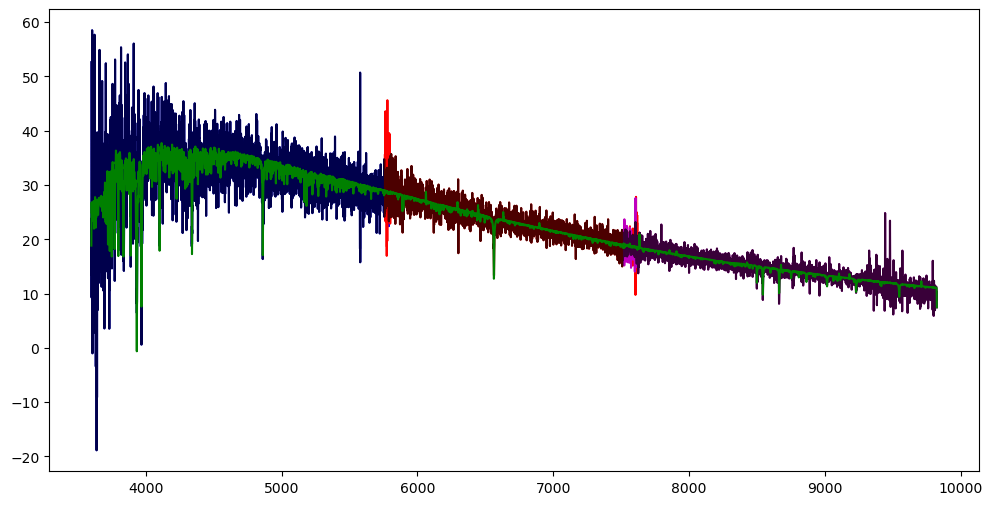

In [165]:
# Plot some spectra (both before and after coadd) and models:
j += 1
plt.figure(figsize=(12,6))
plt.plot(spec_struc.wave['b'], spec_struc.flux['b'][j], 'b')
plt.plot(spec_struc.wave['r'], spec_struc.flux['r'][j], 'r')
plt.plot(spec_struc.wave['z'], spec_struc.flux['z'][j], 'm')
plt.plot(spec_struc_2.wave['brz'], spec_struc_2.flux['brz'][j], 'k', alpha=0.7)
plt.plot(spec_struc_2.wave['brz'], spec_struc_2.extra['brz']['MODEL'][j], 'g')

In [18]:

print('test')

test
